(800, 12)
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


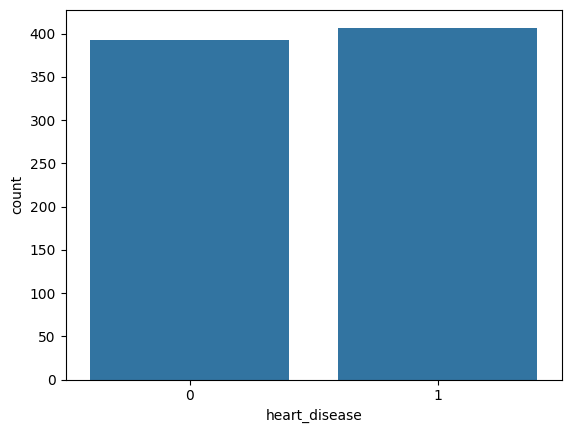

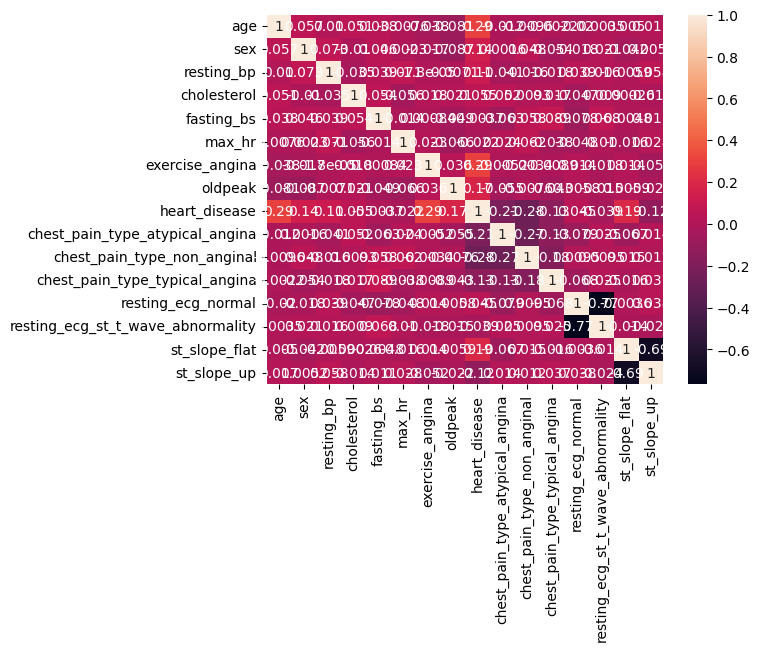

DT
[[67 31]
 [36 66]]
              precision    recall  f1-score   support

           0       0.65      0.68      0.67        98
           1       0.68      0.65      0.66       102

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.66       200
weighted avg       0.67      0.67      0.66       200

RF
[[77 21]
 [17 85]]
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        98
           1       0.80      0.83      0.82       102

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200

GB
[[74 24]
 [20 82]]
              precision    recall  f1-score   support

           0       0.79      0.76      0.77        98
           1       0.77      0.80      0.79       102

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.78       200
weighted

In [ ]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATA
df = pd.read_csv('q1_heart_disease.csv')

# INSPECTION
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

# EDA
sns.countplot(x='heart_disease', data=df)
plt.show()

sns.heatmap(df.corr(), annot=True)
plt.show()

# PREPROCESSING
df.fillna(df.median(numeric_only=True), inplace=True)
df = pd.get_dummies(df, drop_first=True)

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODELS
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "DT": DecisionTreeClassifier(random_state=42),
    "RF": RandomForestClassifier(random_state=42),
    "GB": GradientBoostingClassifier(random_state=42)
}

from sklearn.metrics import classification_report, confusion_matrix

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name)
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))

# TUNING
from sklearn.model_selection import GridSearchCV

params = {'n_estimators':[100,200],'max_depth':[3,5,10]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), params)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)


Dataset is loaded successfully. It contains patient health data used to predict heart disease.


The dataset structure and missing values are checked before preprocessing.


This plot shows how many patients have heart disease and how many do not.


Missing values are handled, categorical variables are encoded, and data is scaled for better model performance.


Hyperparameter tuning is applied to improve model performance.


The heatmap shows relationships between different features in the dataset.
